# Video Segments

This notebook explores the distribution of video segments for the labels: NaturalImages, GaussianDot, Gabor, PinkNoise, and RandomDots.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import sys
from pathlib import Path

repo_root = Path.cwd().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from utils.dataset import DataSet

Define the paths used to access data and metadata.

In [ ]:
# data folder
folder_data = repo_root / 'data'

# metadata folder
folder_meta = repo_root / 'metadata'

# mice/recording folders
all_recording_folders = [
    'dynamic29156-11-10-Video-8744edeac3b4d1ce16b680916b5267ce',
    'dynamic29228-2-10-Video-8744edeac3b4d1ce16b680916b5267ce',
    'dynamic29234-6-9-Video-8744edeac3b4d1ce16b680916b5267ce',
    'dynamic29513-3-5-Video-8744edeac3b4d1ce16b680916b5267ce',
    'dynamic29514-2-9-Video-8744edeac3b4d1ce16b680916b5267ce',
    'dynamic29712-5-9-Video-9b4f6a1a067fe51e15306b9628efea20',
    'dynamic29515-10-12-Video-9b4f6a1a067fe51e15306b9628efea20',
    'dynamic29623-4-9-Video-9b4f6a1a067fe51e15306b9628efea20',
    'dynamic29647-19-8-Video-9b4f6a1a067fe51e15306b9628efea20',
    'dynamic29755-2-8-Video-9b4f6a1a067fe51e15306b9628efea20',
]

Initialize a `DataSet` object to handle the full dataset.

In [3]:
# Inizialize and object from DataSet to handle the dataset
ds = DataSet(folder_data, folder_metadata=folder_meta, recording=all_recording_folders)

# load trials metadata
trials_df = ds.get_trials_metadata()

# load segment metadata
segments_df = ds.get_segments_metadata()

# Mapping from recording name to rec-animalID-session-scan format
mapping = {}
for rec in ds.recording:
    x = rec.split("-")
    mapping[rec] = f"rec-{ds.info[rec]['animal_id']}-{ds.info[rec]['session']}-{ds.info[rec]['scan_idx']}"


Initializing DataSet -------------------------------------------------------------------------------

Checking the data ----------------------------------------------------------------------------------
- All data files seem consistent across trials and data types for recording dynamic29156-11-10-Video-8744edeac3b4d1ce16b680916b5267ce.
- All data files seem consistent across trials and data types for recording dynamic29228-2-10-Video-8744edeac3b4d1ce16b680916b5267ce.
- All data files seem consistent across trials and data types for recording dynamic29234-6-9-Video-8744edeac3b4d1ce16b680916b5267ce.
- All data files seem consistent across trials and data types for recording dynamic29513-3-5-Video-8744edeac3b4d1ce16b680916b5267ce.
- All data files seem consistent across trials and data types for recording dynamic29514-2-9-Video-8744edeac3b4d1ce16b680916b5267ce.
- All data files seem consistent across trials and data types for recording dynamic29712-5-9-Video-9b4f6a1a067fe51e15306b9628efe

## Number of different segments

Count the number of different segment per label. 

`Backgound` refers to segments classify as homogenous frames (single colour)

180 different segments for label NaturalImages
72 different segments for label Gabor
1 different segments for label Background
204 different segments for label PinkNoise
210 different segments for label GaussianDot
96 different segments for label RandomDots


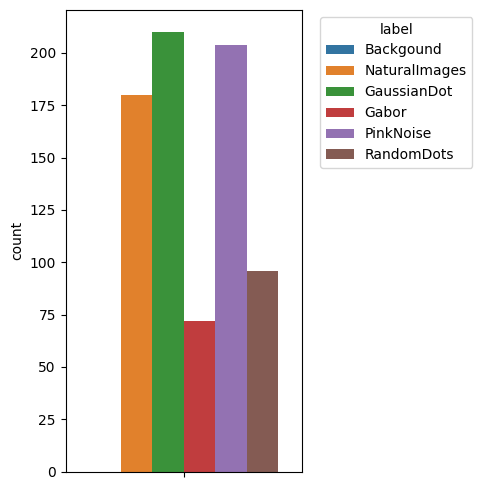

In [6]:
# count the total number of different segment per label
ordered_labels = ["Backgound", 'NaturalImages','GaussianDot','Gabor','PinkNoise','RandomDots']

labels = set(ds.segments_df['segment_label'].to_list())
fig, ax =plt.subplots(nrows=1, ncols=1, figsize=(5, 5))
count_segments = pd.DataFrame(columns=['label', 'count'])
for i, lab in enumerate(labels):
    df_segments_lab = ds.filter_segments(segment_label=lab)
    count = df_segments_lab["segment_ID"].nunique()
    count_segments.loc[len(count_segments)] = [lab, count]
    print(f"{count} different segments for label {lab}")
ax = sns.barplot(data=count_segments, y="count", hue="label", hue_order=ordered_labels)
ax.legend(
    title="label",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
fig.tight_layout()
fig.savefig(Path(repo_root, 'figures', f"count-segments-labels.png"), dpi=300)


## Segment occurrence per recording

For each recording, count how many times each segment appears and plot a histogram showing the count distribution.

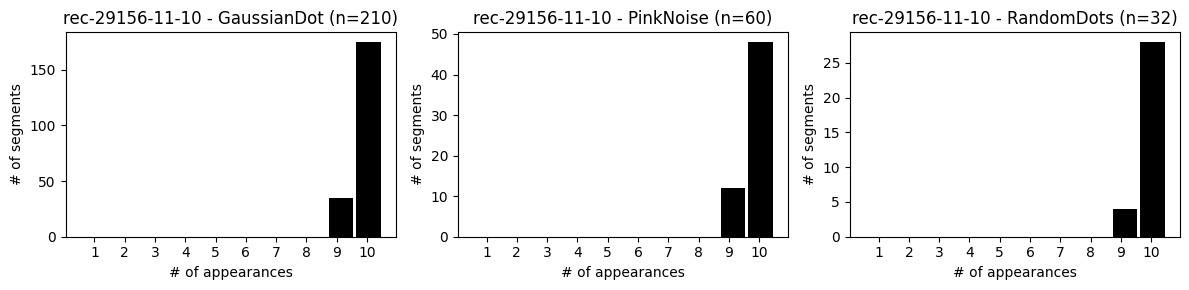

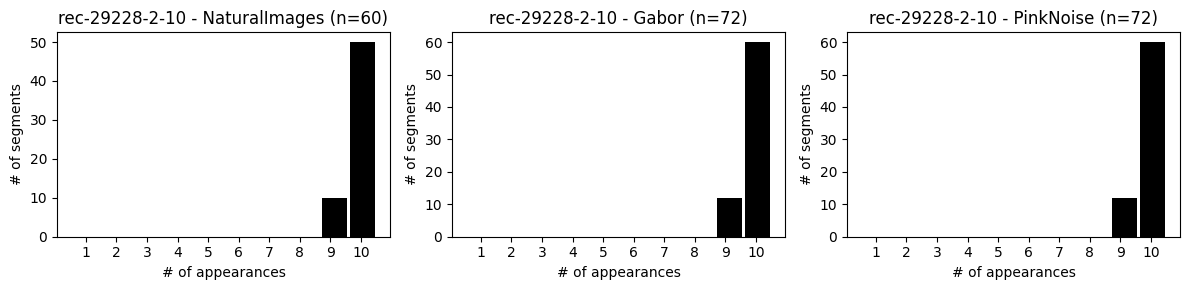

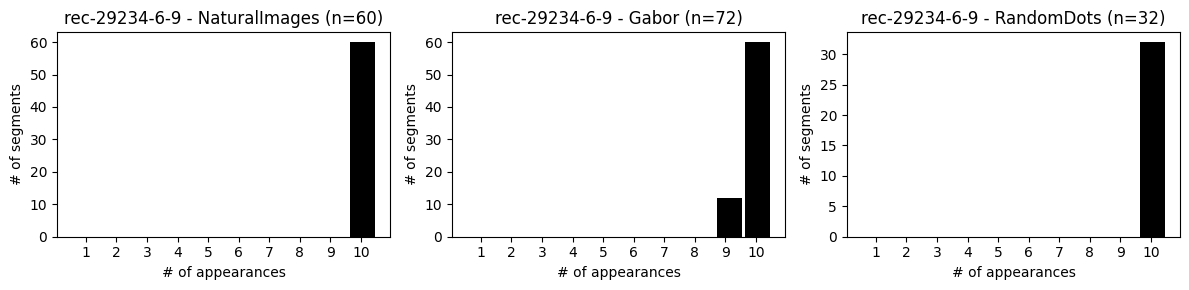

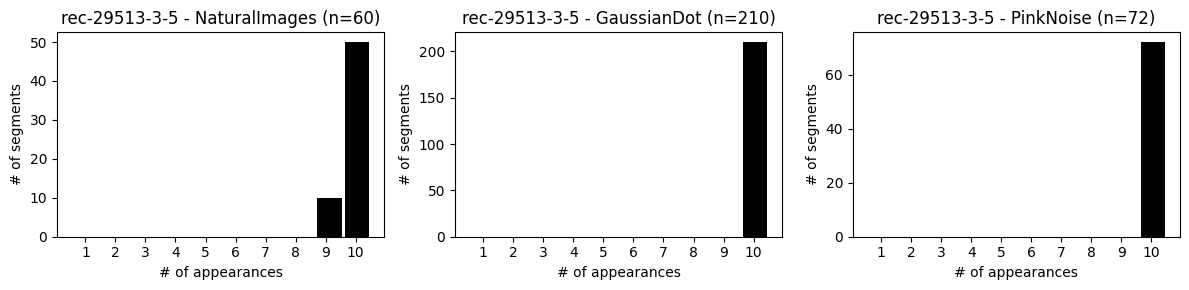

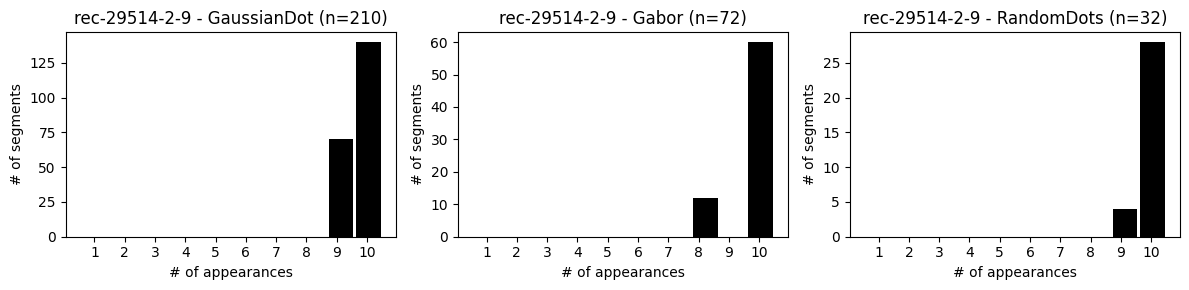

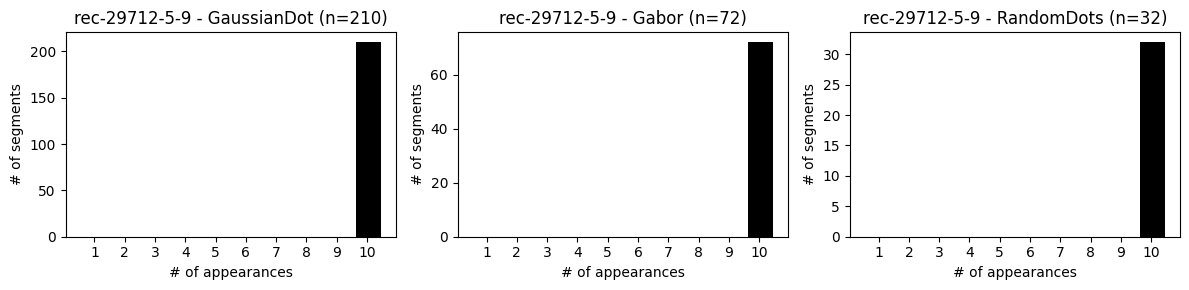

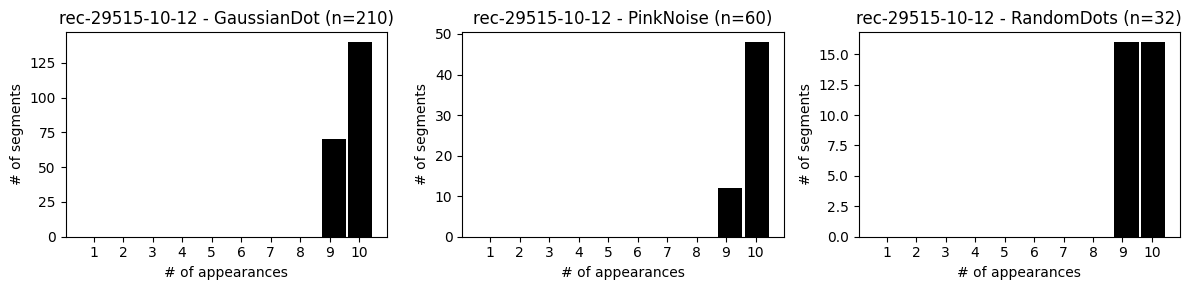

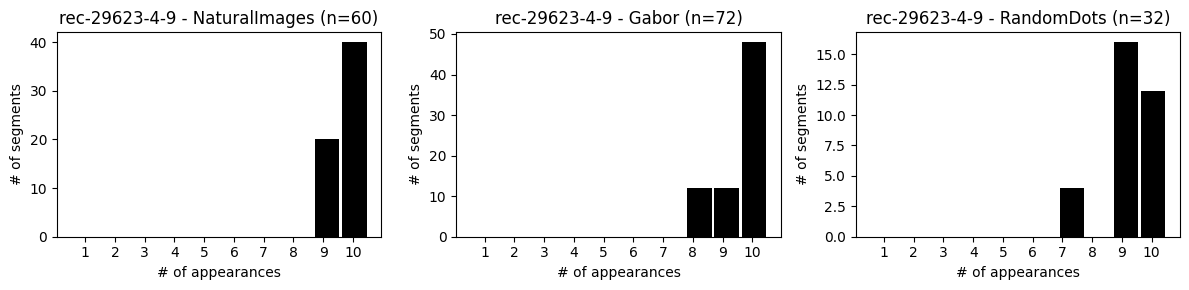

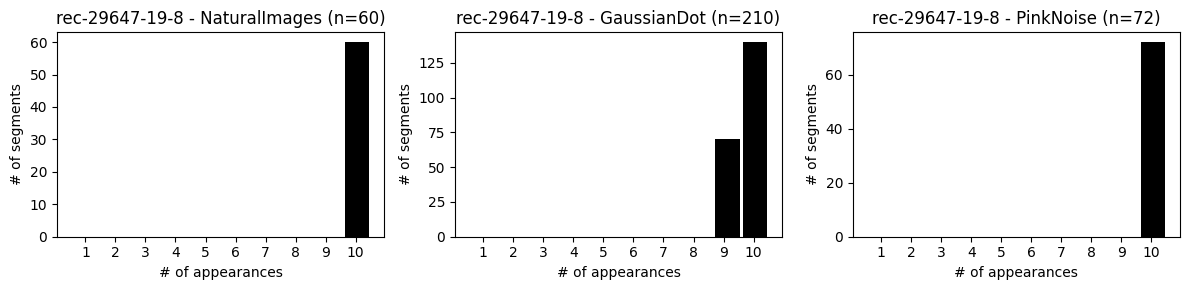

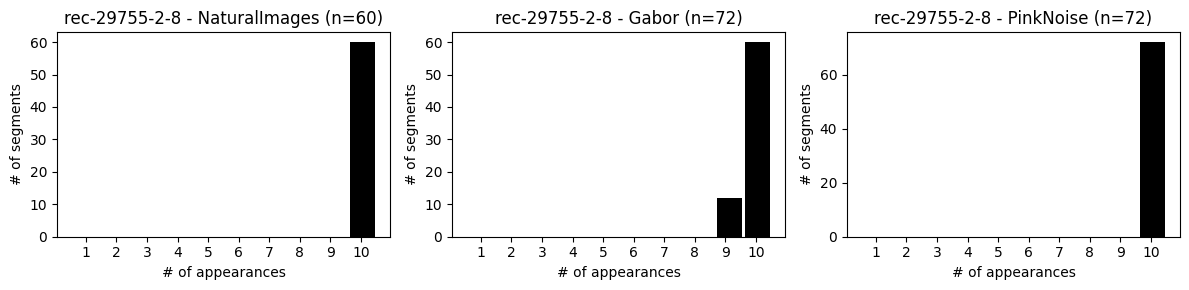

In [7]:
# count the number of occurences of each segment per recording
counts = ds.count_segments_across(["segment_ID","recording","segment_label"])
ordered_labels = ["Backgound", 'NaturalImages','GaussianDot','Gabor','PinkNoise','RandomDots']

for rec in ds.recording:
    all_segments_df_rec = ds.filter_segments(recording=rec)
    labels = set(all_segments_df_rec['segment_label'].to_list())
    labels.discard("Background")
    labels = [x for x in ordered_labels if x in labels]

    fig, ax =plt.subplots(nrows=1, ncols=3, figsize=(12, 3))
    for i, label in enumerate(labels):
        d = counts[(counts['recording']==rec) & (counts['segment_label']==label)]['count'].to_numpy()
        xmax = np.max(d)
        h = ax[i].hist(d, range=(.5, xmax+0.5), bins=xmax+1, color='k',rwidth=0.9)
        ax[i].set_xticks(np.arange(1,xmax+1))
        ax[i].set_title(f"{mapping[rec]} - {label} (n={len(d)})")
        ax[i].set_xlabel("# of appearances")
        ax[i].set_ylabel("# of segments")
    fig.tight_layout()
    fig.savefig(Path(repo_root, 'figures', f"count-segments-labels_{mapping[rec]}.png"), dpi=300)

## Segment occurrence across recordings

Count, for each segment ID, in how many recordings it appears.
Then plot a histogram of the recording counts.

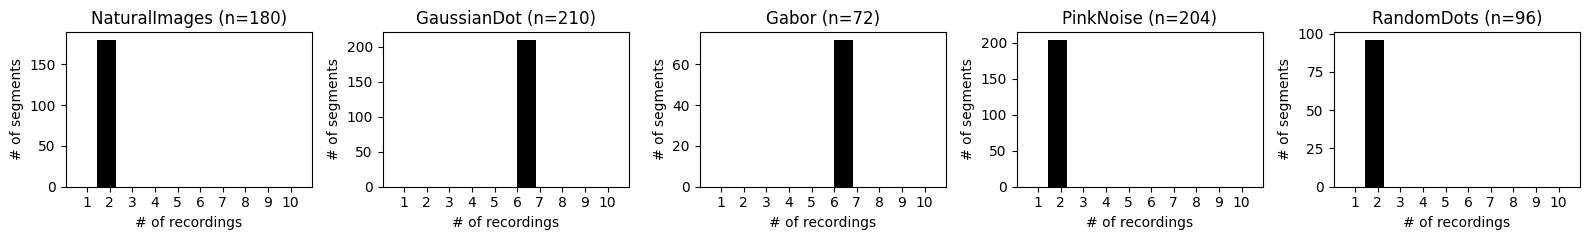

In [11]:
labels = ['NaturalImages','GaussianDot','Gabor','PinkNoise','RandomDots']

fig, ax =plt.subplots(nrows=1, ncols=len(labels), figsize=(16, 2.5))
xmax = 10
for i, lab in enumerate(labels):
    df_segments_lab = ds.filter_segments(segment_label=lab)
    count_recordings = df_segments_lab.groupby("segment_ID")["recording"].nunique()
    count_recordings = count_recordings.reset_index()
    count_recordings.columns = ["segment_ID"]+["n_recordings"]
    d = count_recordings["n_recordings"].to_numpy()
    h = ax[i].hist(d, range=(.5, xmax+0.5), bins=xmax+1, color='k',rwidth=0.9)
    ax[i].set_xticks(np.arange(1,xmax+1))
    ax[i].set_title(f"{lab} (n={len(d)})")
    ax[i].set_xlabel("# of recordings")
    ax[i].set_ylabel("# of segments")
plt.tight_layout()
fig.savefig(Path(repo_root, 'figures', f"count-recordings-x-segment_x-label.png"), dpi=300)
